# Exercise 2: Dimension Reduction on Mice Protein Expression Dataset

In this notebook, we analyse the "Data_Cortex_Nuclear.xls" dataset to understand the effects of memantine treatment on Ts65Dn mice and wildtype controls in the shock-context (SC) condition. 

We aim to answer these three questions based on our visualizations:
1. When comparing treatment with memantine vs. saline solution, does the treatment have a measureable effects on Ts65Dn mice (t-SC)? Does it also have an effect on wildtype controls (c-SC)?
2. Do the expression profiles of Ts65Dn mice and wildtype controls differs without effective treatment (saline solution)?
3. Do the expression profiles of Ts65Dn mice who have treated with memantine become indistinguishenable from those of wildtype controls (either with or without treatment)? If not, do they become more similar?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

## a) Data Preparation

First, we will read the dataset, remove any rows that contain missing values, and select the specific classes we are interested in:
- c-SC-s: Wildtype (control), shock-context, saline (no treatment)
- c-SC-m: Wildtype (control), shock-context, memantine (treatment)
- t-SC-s: Ts65Dn (Down syndrome model), shock-context, saline (no treatment)
- t-SC-m: Ts65Dn (Down syndrome model), shock-context, memantine (treatment)

In [ ]:
# Read the excel file
df = pd.read_excel('Data_Cortex_Nuclear.xls')

# Drop rows with any missing values
df_clean = df.dropna()

# Filter for the relevent classes
target_classes = ['c-SC-s', 't-SC-s', 'c-SC-m', 't-SC-m']
df_filtered = df_clean[df_clean['class'].isin(target_classes)].copy()

# Check how many items remain for each class
print("Number of items remaining for each class:")
print(df_filtered['class'].value_counts().to_string())

Number of items remaining for each class:
class
c-SC-s    75
t-SC-s    72
c-SC-m    60
t-SC-m    60


## b) PCA (Principal Component Analysis)

Now, we will separate the 77 protein expression levels from the meta information (like MouseID, Genotype, etc.). Then, we will aply PCA to reduce the data to 2 dimensions and visualize it.

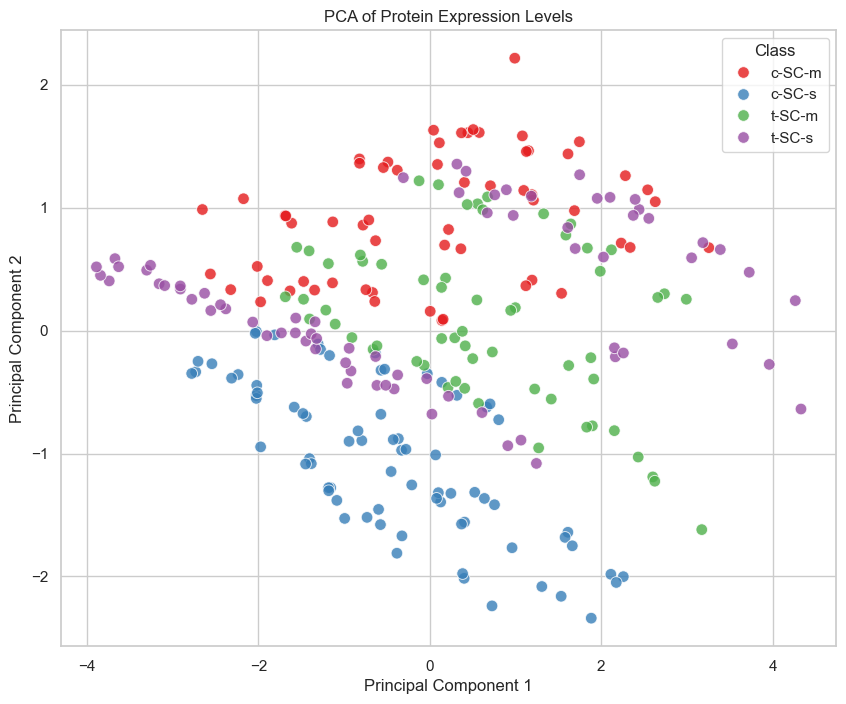

In [5]:
# Extract the 77 protein expression columns
# Column 0 is MouseID, Columns 1 to 77 are proteins, the last 4 are meta information
X = df_filtered.iloc[:, 1:78].values
y = df_filtered['class'].values

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for visualization
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['class'] = y

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='class', data=df_pca, palette='Set1', s=70, alpha=0.8)
plt.title('PCA of Protein Expression Levels')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Class')
plt.show()

### PCA Observations:
Based on the PCA plot, we try to answer the questions:
1. Treatment effect: The treatment has a very clear and subtantial effect on the wildtype controls; "c-SC-m" (red) and "c-SC-s" (blue) are widely separated. For the Ts65Dn mice, the effect is measurable but less uniform; the treated ("t-SC-m", green) and untreated ("t-SC-s", purple) groups have some overlap and spread out broadly across the horizontal axis (PC1), indicating a more varied individual response to the treatment.
2. Difference without treatment: The "t-SC-s" (purple, untreated Ts65Dn) and "c-SC-s" (blue, untreated control) clusters show clear separation, indicating a natural difference in their basic protein expression profiles.
3. Similarity after treatment: The treated Ts65Dn mice ("t-SC-m", green) do not become indistinguishable from the controls. They form their own region that does not fully overlap with either "c-SC-m" or "c-SC-s". While their profile changes due to the drug, it does not match the healthy profile.

## c) ISOMAP

We will produce a similar plot using ISOMAP. We will test a few values for the number of neighbors (n_neighbors) to find a good representation.

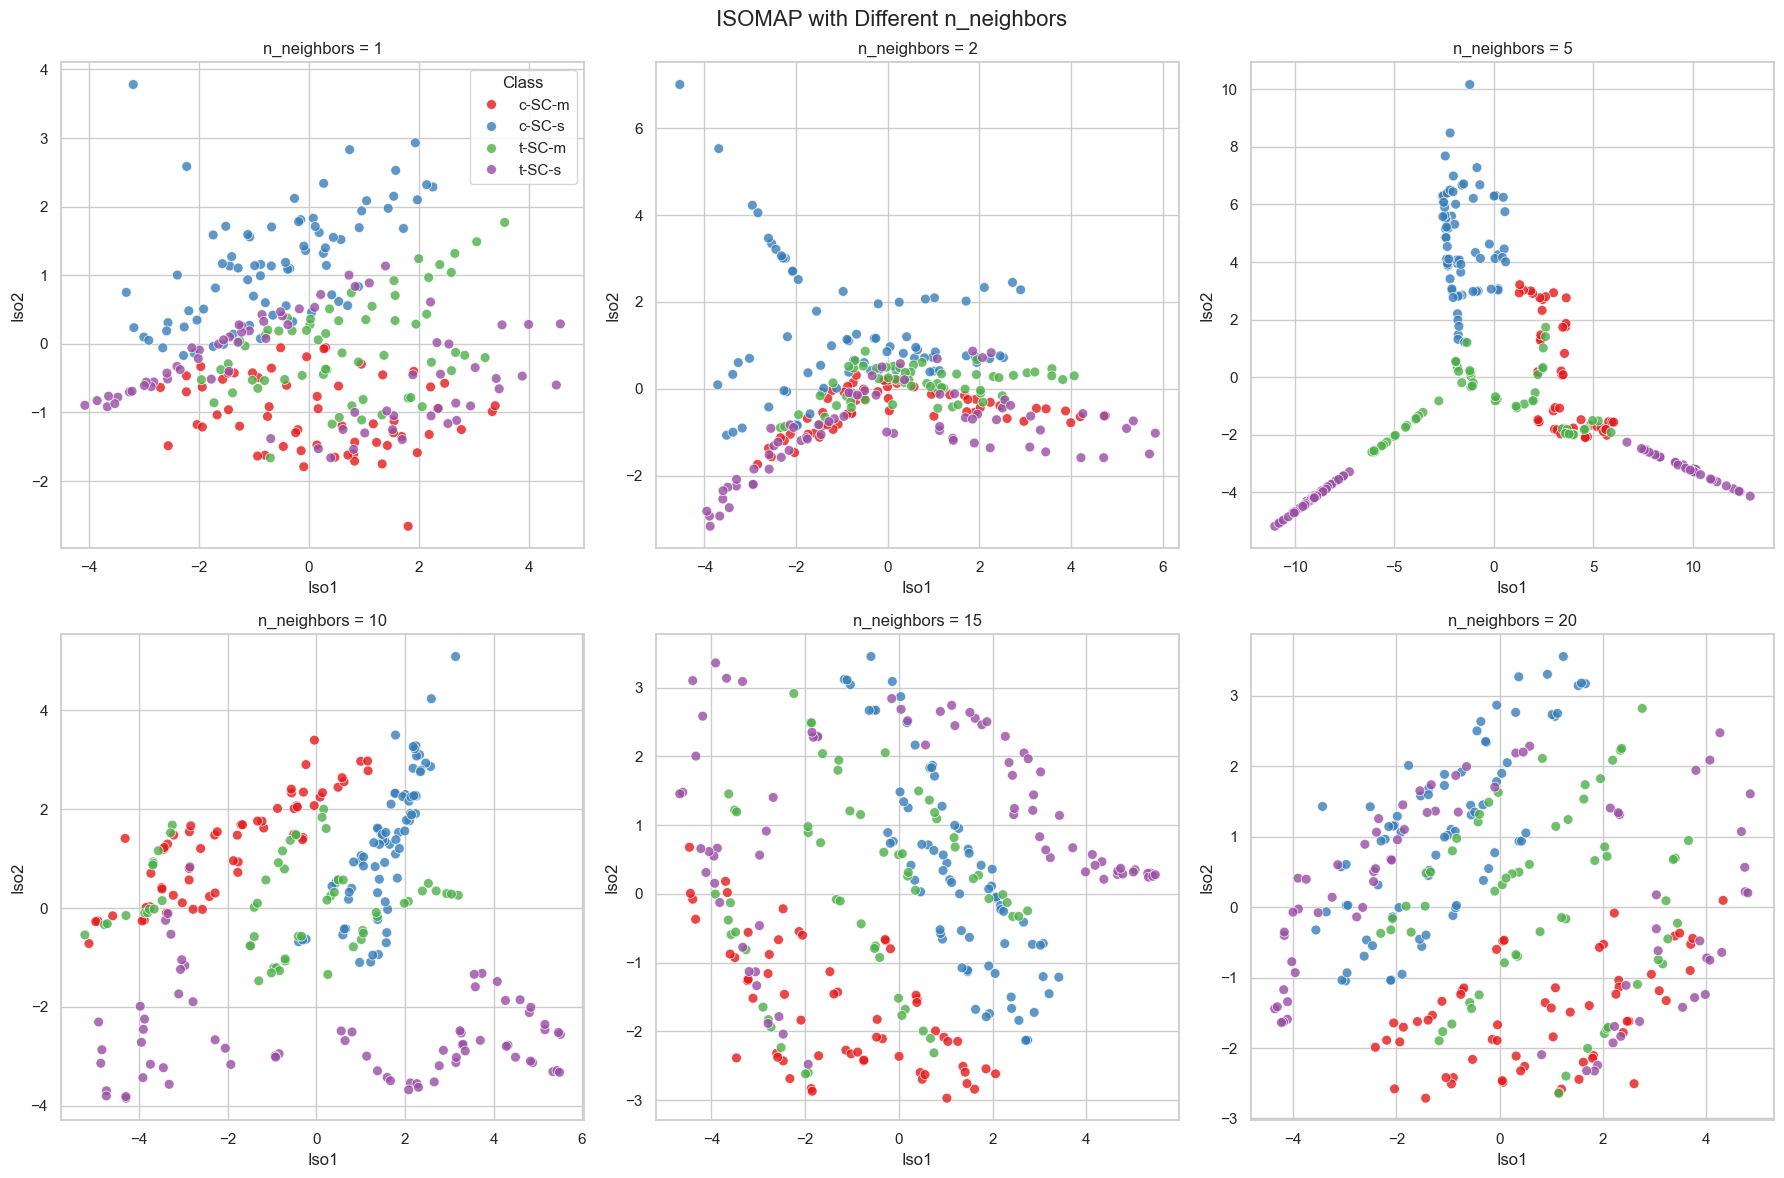

In [18]:
# Try values from very small to our chosen sweet spot
neighbors = [1, 2, 5, 10, 15, 20]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('ISOMAP with Different n_neighbors', fontsize=16)
axes = axes.flatten()

for i, n in enumerate(neighbors):
    isomap = Isomap(n_neighbors=n, n_components=2)
    X_iso = isomap.fit_transform(X)
    
    df_iso = pd.DataFrame(data=X_iso, columns=['Iso1', 'Iso2'])
    df_iso['class'] = y
    
    sns.scatterplot(ax=axes[i], x='Iso1', y='Iso2', hue='class', data=df_iso, palette='Set1', s=50, alpha=0.8)
    axes[i].set_title(f'n_neighbors = {n}')
    
    # We only need one legend for the first plot
    if i > 0:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title='Class')

plt.tight_layout()
plt.show()

### ISOMAP Observations:

Choosing "n_neighbors":
We tested "n_neighbors" from 1 to 20 to find the best representation. 
- When "n_neighbors" is 1 or 2 (too small), the algorithm connects too few points. The data looks completely scattered and broken without any meaning. 
- When "n_neighbors = 5", the points start to form structures, but they are still disconnected into small, unnatural islands.
- When "n_neighbors" goes up to 15 or 20 (too large), we see "short-circuiting". The algorithm connects points across different regions incorrectly, making the different colors mix into a single cloud (similar to PCA).
- We choose 10 as our final value because it provides the best balance. At 10, the healthy groups (blue and red) show good internal consistency and clear borders. While the purple group ("t-SC-s") remains scattered due to its natural high variance, the overall map avoids both the extreme fragmentation of 1-5 and the cloudy mixing of 15-20.

Comparing with PCA and Answering our Questions:

Our answers do not change from PCA. ISOMAP captures non-linear patterns, so the clusters have different shapes. However, the main results remain similar:
1. The treatment clearly affects the mice.
2. The healthy mice and Ts65Dn mice have different profiles without treatment.
3. Treated Ts65Dn mice ("t-SC-m") do not perfectly match the healthy mice. They still remain separated.

## d) t-SNE

Next, we use t-SNE. We will experiment with the "perplexity" parameter.

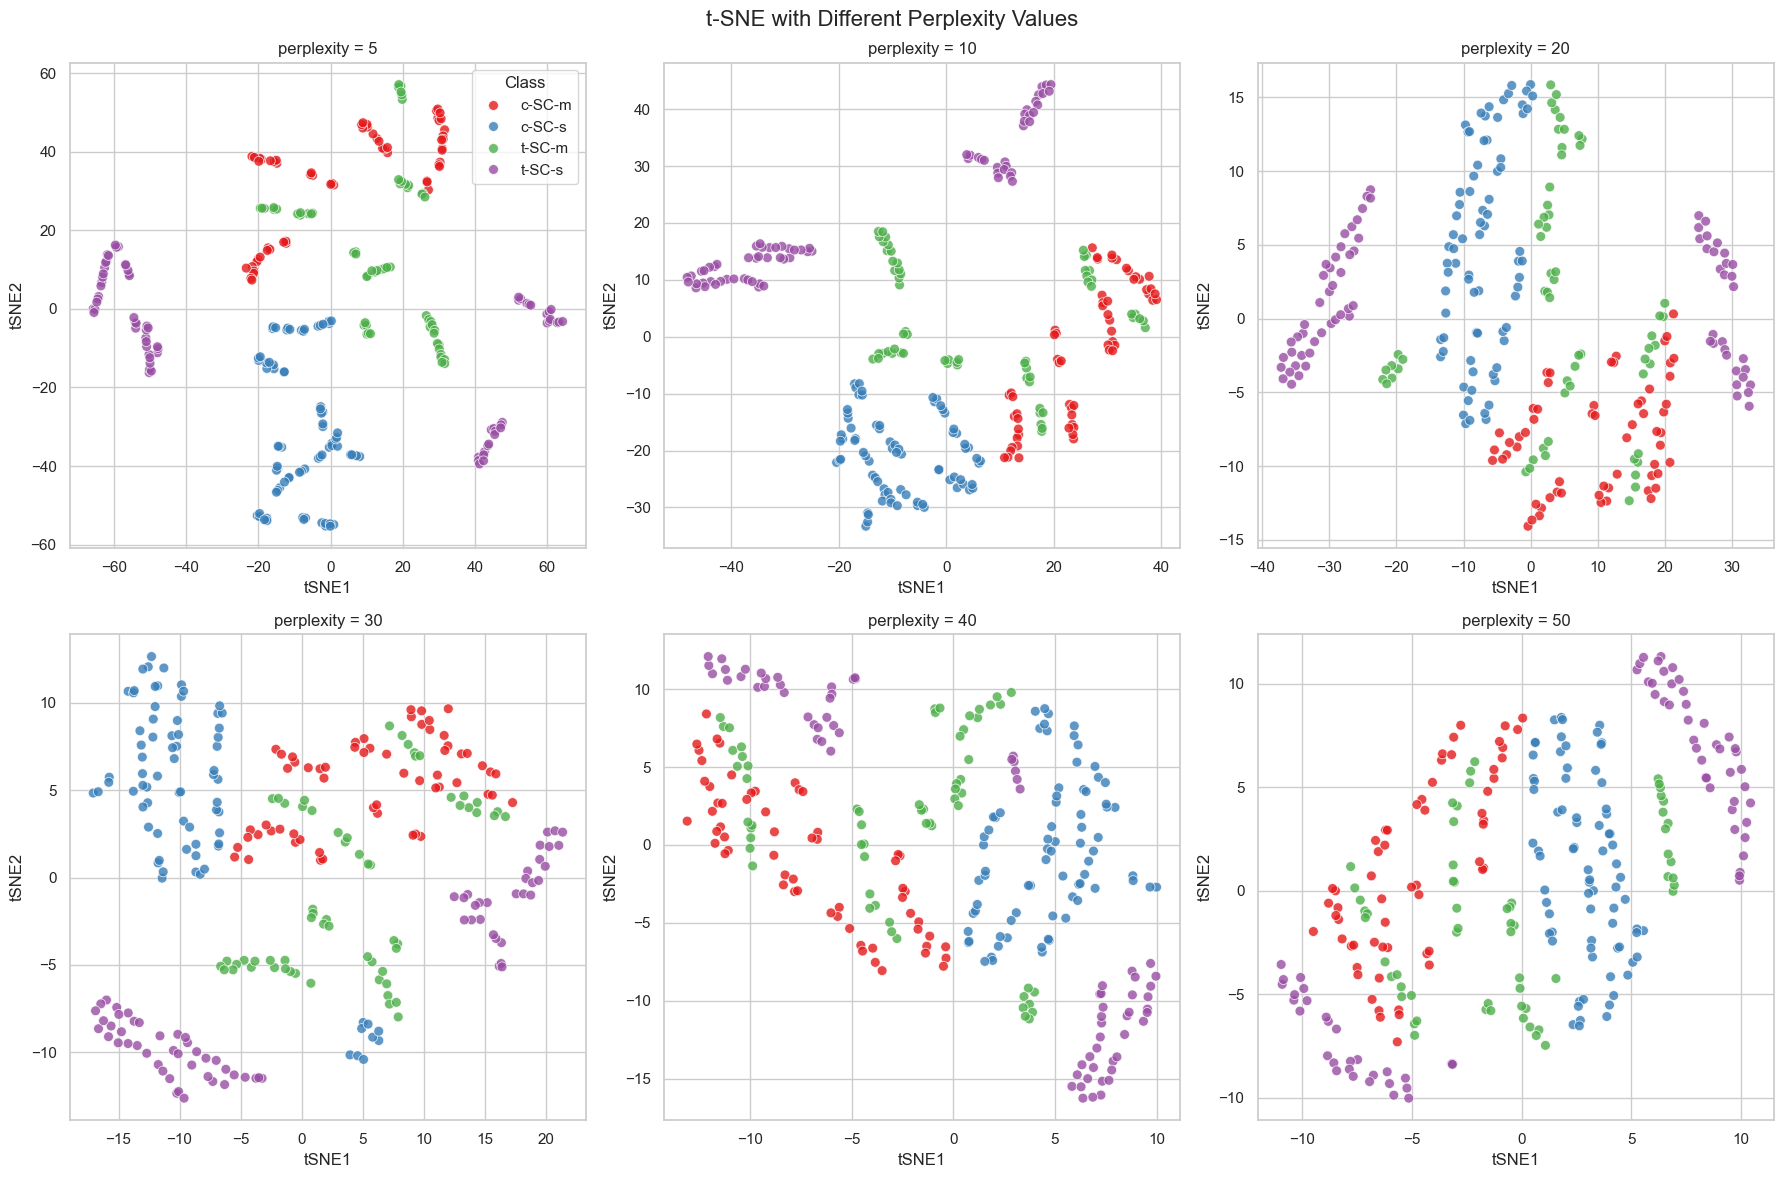

In [19]:
# Try different perplexity values for t-SNE
perplexities = [5, 10, 20, 30, 40, 50]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('t-SNE with Different Perplexity Values', fontsize=16)
axes = axes.flatten()

for i, p in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    X_tsne = tsne.fit_transform(X)
    
    df_tsne = pd.DataFrame(data=X_tsne, columns=['tSNE1', 'tSNE2'])
    df_tsne['class'] = y
    
    sns.scatterplot(ax=axes[i], x='tSNE1', y='tSNE2', hue='class', data=df_tsne, palette='Set1', s=50, alpha=0.8)
    axes[i].set_title(f'perplexity = {p}')
    
    if i > 0:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title='Class')

plt.tight_layout()
plt.show()

### t-SNE Observations:

Choosing "perplexity": 
We tested perplexity values from 5 to 50. Perplexity balances the algorihtm's attention between local and global rules (it acts like a guess for the number of close neighbors).
- When "perplexity = 5" (too low), the algorithm focuses too much on local noise. The data breaks into many tiny, meaningless islands.
- When "perplexity = 50" (too high for our dataset size of 267), the clusters start to lose their tight shapes and drift towards each other. 
- We choose 30 as our final value. It cleanly groups the same classes together while keeping the different clusters separated, providing the most meaningful representation.

Comparing with ISOMAP and Answering our Questions:
t-SNE separates groups much more strictly and clearly than ISOMAP, resulting in tighter blobs. However, our biological answers remain consistent:
1. Treatment effect: Yes, memantine has a clear effect. Wildtype controls ("c-SC-m" and "c-SC-s") are in completely different clusters. Ts65Dn mice also show a shift, proving the treatment works on both groups.
2. Difference without treatment: Yes. Untreated Ts65Dn ("t-SC-s", purple) and untreated controls ("c-SC-s", blue) are distinctly separated.
3. Similarity after treatment: Treated Ts65Dn mice ("t-SC-m", green) form their own distinct cluster. They do not perfectly mix with the wildtype controls, meaning they become different but not identical to healthy mice.

## e) LDA (Linear Discriminant Analysis)

Finally, we apply LDA. Unlike the previous methods (PCA, ISOMAP, t-SNE) which are unsupervised, LDA is a supervised method. This means it uses the actual class labels to find axes that maximize the separation between the known classes.

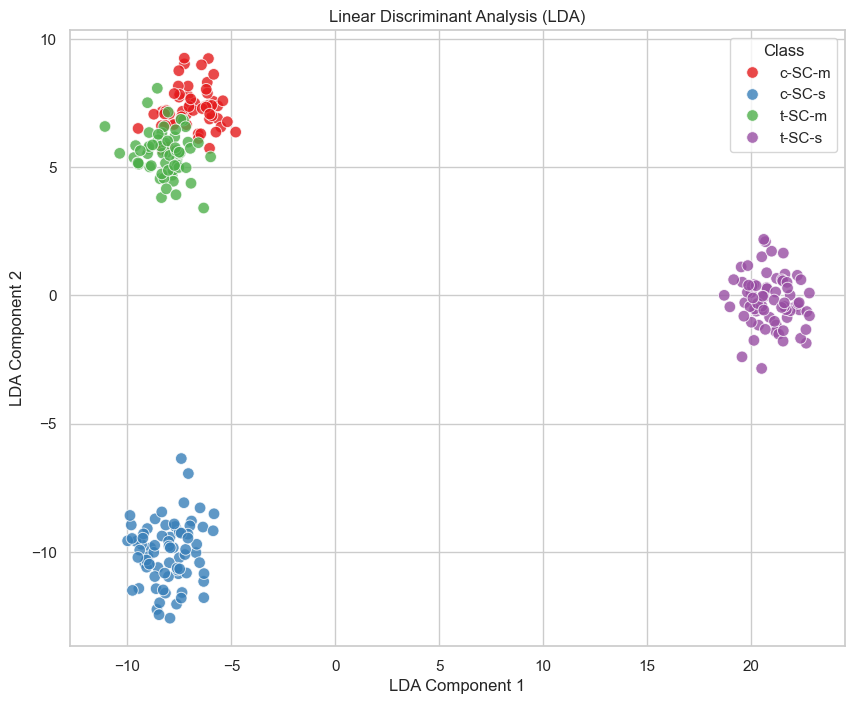

In [20]:
# Apply LDA
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y) # Note that we pass 'y' here because LDA is supervised

df_lda = pd.DataFrame(data=X_lda, columns=['LDA1', 'LDA2'])
df_lda['class'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(x='LDA1', y='LDA2', hue='class', data=df_lda, palette='Set1', s=70, alpha=0.8)
plt.title('Linear Discriminant Analysis (LDA)')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.legend(title='Class')
plt.show()

### LDA Observations:
Unlike PCA, ISOMAP, and t-SNE (which are unsupervised), LDA is a supervised method. It actively uses the actual class labels (y) to find the axes that maximize the separation between those known classes. Because of this, the clusters in this plot look completely distinct and are pushed artificially far apart compared to the other methods. 

Does this supervised view change our answers?
1. Treatment effect: No, it strongly confirms it. LDA shows a massive separation between treated ("-m") and untreated ("-s") groups for both wildtype and Ts65Dn mice. The treatment effect is made to look incredibly clear.
2. Difference without treatment: No change. The separation between untreated Ts65Dn ("t-SC-s") and untreated controls ("c-SC-s") is huge here, leaving no doubt that their baseline expression profiles differ.
3. Similarity after treatment: No change. Even though the treated Ts65Dn ("t-SC-m", green) mice have shifted due to the drug, they are cleanly separated into their own quadrant away from the wildtype controls ("c-SC-m" or "c-SC-s"). They do not become indistinguishable from healthy mice.

**Conclusion:** 
LDA makes all differences look much more significant and perfect because it is specifically designed to pull the classes apart. However, our fundamental biological answers from the unsupervised methods remain exactly the same: the profiles differ natively, the drug works, but it does not make the sick mice identical to the healthy ones.